# Project: Data-driven Insights using Python: FoodHub Data Analysis



# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Let us start by importing the required libraries

In [1]:
# Note: The following libraries are required. Install if needed before running.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Understanding the structure of the data

In [3]:
# Write your code here to read the data
df = pd.read_csv('foodhub_order.csv')

In [4]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [5]:
# Write your code here
print('There are',df.shape[0], 'rows and', df.shape[1],'columns in this dataset.')

There are 1898 rows and 9 columns in this dataset.


#### Observations:
There are 1898 Rows and 9 Columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [6]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
4 columns contain objects, 4 contain integers, and 1 contains floats.
Rating is an Object and may need to be cleaned and/or converted for certain operations. (Handled below).

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [7]:
# Write your code here
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

We see that there are no missing (null) values, but did notice above some "Not given" under rating.  We also noticed that rating was an object rather than a float or integer.

In [8]:
#Looking further into rating since one would expect an int or float and not an object:
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [9]:
df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

Here we can see that of the 1898 orders, 736 were not rated.

In [10]:
#Creating a cleaned copy with "Not given" converted to nan and rating type converted to float
#I opted to create a copy so that I can still handle the "Not given" value in the original df since it might tell us something about who is not rating what
df_c = df.copy()
df_c["rating"] = df_c["rating"].replace("Not given", np.nan)
df_c["rating"] = df_c["rating"].astype("Int64")
df_c['rating'].dtype

Int64Dtype()

In [11]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
df['order_id'].nunique()

1898

#### Observations:
There are no missing (null) values in this dataframe.

There are ratings "Not given", but this is legitimate data with insights to offer on who is not rating and why.  For treatment, a cleaned copy of the dataframe was created where "Not given" has been converted to nan and 'rating' has been converted to a float.  This way I can still display not given values in graphs with ease.

There are no duplicate rows or orders IDs.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [13]:
# Write your code here
df_c.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.0,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.0,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.0,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.0,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.0,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.0,35.000000,33.000000


#### Observations:
Minimum Preparation Time: 20.00 min.

Average Preparation Time: 27.37 min.

Maximum Preparation Time: 35.00 min.

### **Question 5:** How many orders are not rated? [1 mark]

In [14]:
# Write the code here
df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

In [15]:
#Normalized
df['rating'].value_counts(dropna = False, normalize = True)

rating
Not given    0.387777
5            0.309800
4            0.203372
3            0.099052
Name: proportion, dtype: float64

#### Observations:
736 orders do not have a rating accounting for approximately 39% of all orders in the dataframe.

# Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

**CUSTOMER ID**

In [16]:
# Write the code here

#Count of orders per customer
order_count = df['customer_id'].value_counts()
order_count.sort_values(ascending = False).head()

customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
Name: count, dtype: int64

Observations:

1200 customers made up the 1898 orders with the highest number of orders from a single customer being 13.

In [17]:
#Comparing orders per customer
print((df["customer_id"].value_counts() == 1).sum(),'customers had only one order in the data set')
print((df["customer_id"].value_counts() > 1).sum(),'customers had more than one order in the data set')
print((df["customer_id"].value_counts() > 5).sum(),'customers had more than five orders in the data set')

784 customers had only one order in the data set
416 customers had more than one order in the data set
14 customers had more than five orders in the data set


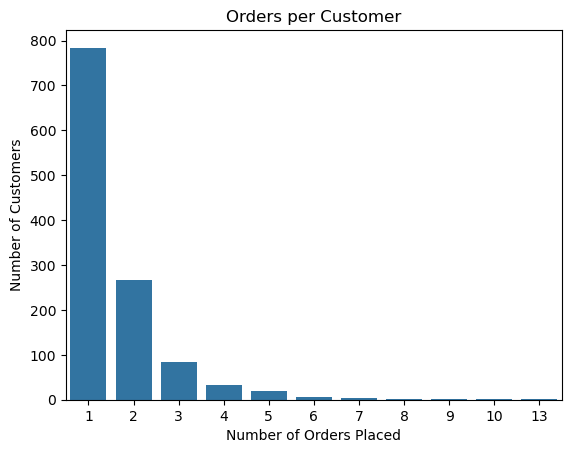

In [18]:
#Placing this information into a countplot to visualize
sns.countplot(x=df['customer_id'].value_counts())
plt.title('Orders per Customer')
plt.xlabel('Number of Orders Placed')
plt.ylabel('Number of Customers')
plt.show()

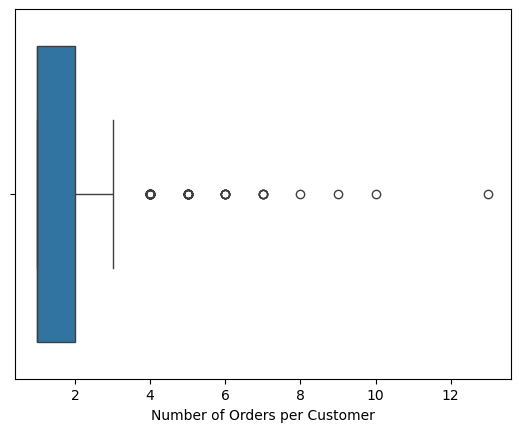

In [19]:
#Boxplot of number of orders per customer
sns.boxplot(x=df['customer_id'].value_counts())
plt.xlabel('Number of Orders per Customer')
plt.show()

In [20]:
#Describing the boxplot:
Q1 = df['customer_id'].value_counts().quantile(0.25)
Q3 = df['customer_id'].value_counts().quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
df['customer_id'].value_counts().describe()

Lower Outlier Fence = -0.5
Upper Outlier Fence = 3.5


count    1200.000000
mean        1.581667
std         1.090560
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        13.000000
Name: count, dtype: float64

In [21]:
print((df["customer_id"].value_counts() > 3.5).sum(),'customers ordered 4 or more times and are outliers in the above boxplot')

66 customers ordered 4 or more times and are outliers in the above boxplot


Observations:

The countplot and boxplot show us that the data is right skewed.

The vast majority of customers ordered only once or twice in the measured period, but there are quite a few outliers.

**Restaurants**

In [22]:
#Next looking at restaurant_name

#Orders Per Restaurant:
orders_per_restaurant = df['restaurant_name'].value_counts()
orders_per_restaurant.sort_values(ascending = False).head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

Observations:

We see that the 1898 orders were distributed among 178 total restaurants

Shake Shack had the most orders at 219.
Only 3 restaurants had >100 orders

In [23]:
print((df["restaurant_name"].value_counts() == 1).sum(),'restaurants had only one order in the data set')
print((df["restaurant_name"].value_counts() > 1).sum(),'restaurants had more than one order in the data set')
print((df["restaurant_name"].value_counts() > 10).sum(),'restaurants had more than ten orders in the data set')

50 restaurants had only one order in the data set
128 restaurants had more than one order in the data set
40 restaurants had more than ten orders in the data set


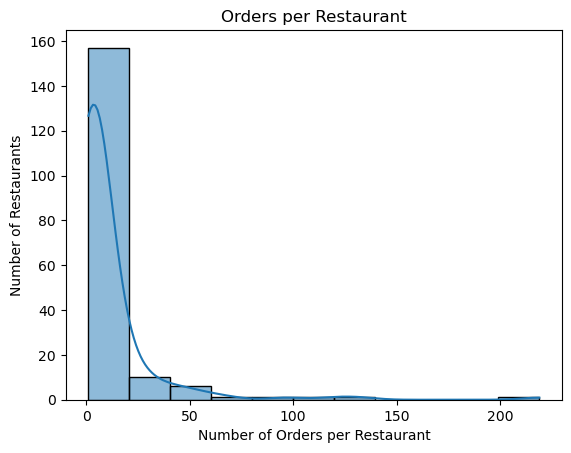

In [24]:
#Placing this information into a histogram to visualize (Countplot could be used, but was too cluttered visually)
sns.histplot(df['restaurant_name'].value_counts(), binwidth = 20, kde=True)
plt.title('Orders per Restaurant')
plt.xlabel('Number of Orders per Restaurant')
plt.ylabel('Number of Restaurants')
plt.show()

Observations:

Here we see that the vast majority of restaurants had between 0 and 20 orders, but that the data has a right skew with outliers reaching as high as 219 orders.

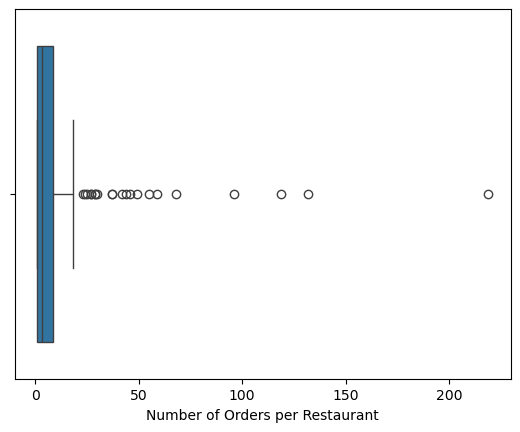

In [25]:
#Boxplot of number of orders per restaurant
sns.boxplot(x=df['restaurant_name'].value_counts())
plt.xlabel('Number of Orders per Restaurant')
plt.show()

In [26]:
#Describing the Boxplot:
Q1 = df['restaurant_name'].value_counts().quantile(0.25)
Q3 = df['restaurant_name'].value_counts().quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
df['restaurant_name'].value_counts().describe()

Lower Outlier Fence = -10.625
Upper Outlier Fence = 20.375


count    178.000000
mean      10.662921
std       24.047008
min        1.000000
25%        1.000000
50%        3.000000
75%        8.750000
max      219.000000
Name: count, dtype: float64

Observations:

A boxplot shows the distribution of data and that restaurants with >20 orders in the time period measured are outliers.

**Cuisine Type**

In [27]:
#Number of orders by type of cuisine
orders_per_type = df['cuisine_type'].value_counts()
orders_per_type.sort_values(ascending = False)

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

Observations:

We see that the 1898 orders and 178 restaurants are split among 14 types of food.

American style food was ordered the most with 584 total orders

Only 4 food types had >100 orders: American, Japanese, Italian, and Chinese

Vietnamese food was ordered least with 7 orders

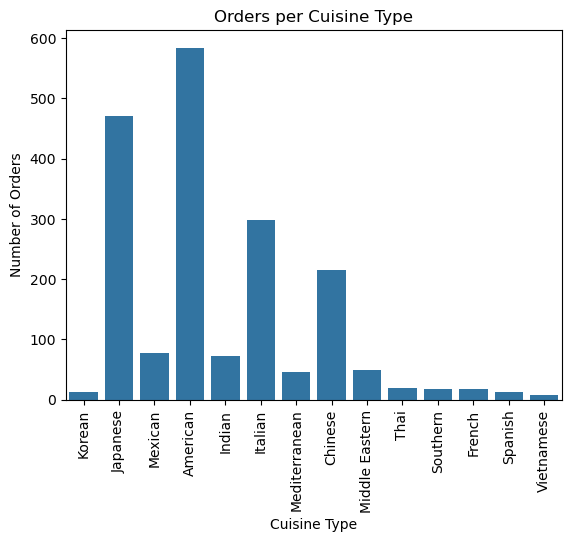

In [28]:
#Placing this information into a countplot to visualize
sns.countplot(data=df, x="cuisine_type")
plt.title('Orders per Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.show()

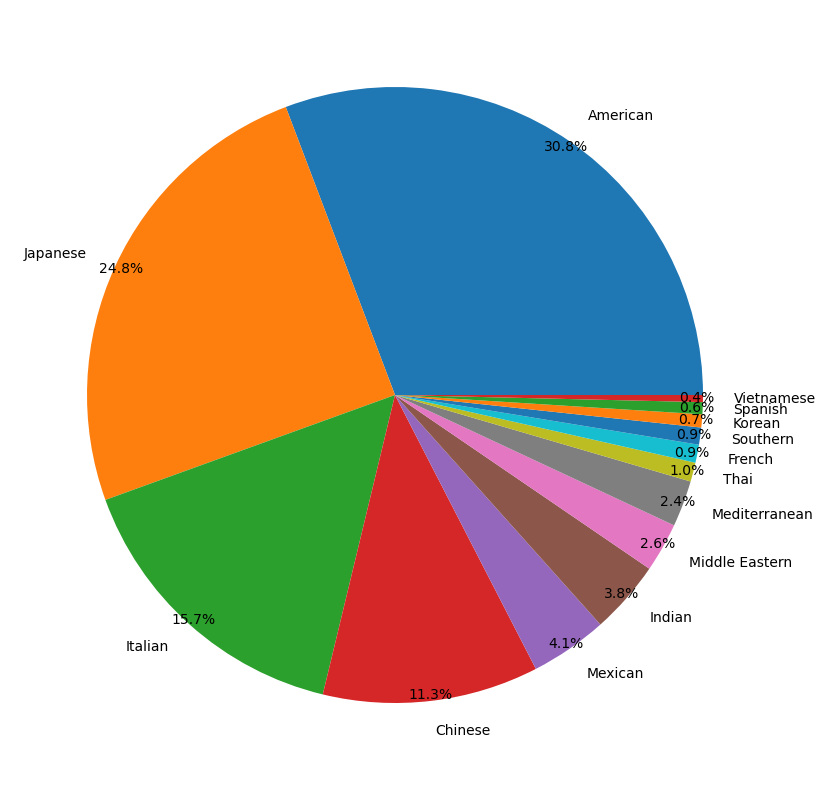

In [29]:
#Pie Chart to show share of total:
plt.figure(figsize=(10,10))
plt.pie(orders_per_type.values, labels=orders_per_type.index, autopct='%1.1f%%', pctdistance=.98)
plt.show()

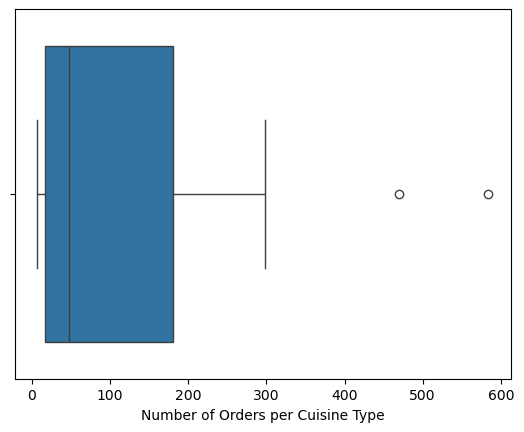

In [30]:
#Boxplot of orders per cuisine type
sns.boxplot(x=df['cuisine_type'].value_counts())
plt.xlabel('Number of Orders per Cuisine Type')
plt.show()

In [31]:
#Describing the Boxplot
Q1 = df['cuisine_type'].value_counts().quantile(0.25)
Q3 = df['cuisine_type'].value_counts().quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
df['cuisine_type'].value_counts().describe()

Lower Outlier Fence = -227.625
Upper Outlier Fence = 425.375


count     14.000000
mean     135.571429
std      187.448748
min        7.000000
25%       17.250000
50%       47.500000
75%      180.500000
max      584.000000
Name: count, dtype: float64

Observations:

Here we see there are 2 outliers with >425 orders - American and Japanese Cuisine

**Cost of Order**

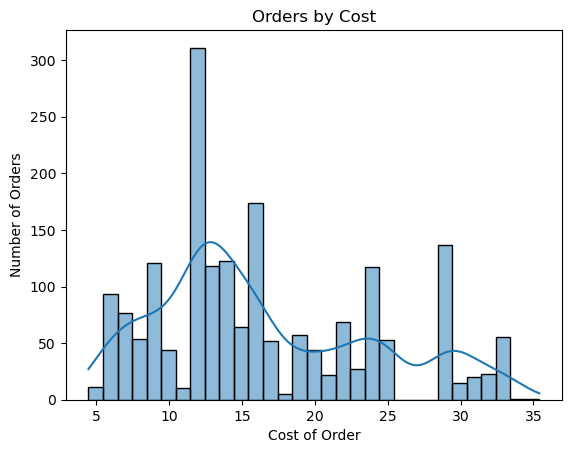

In [32]:
#Starting with a histogram:
sns.histplot(df['cost_of_the_order'], binwidth= 1, kde=True)
plt.title('Orders by Cost')
plt.xlabel('Cost of Order')
plt.ylabel('Number of Orders')
plt.show()

In [33]:
#Count of orders at each cost point
orders_per_cost = df['cost_of_the_order'].value_counts()
orders_per_cost.sort_values(ascending = False).head()

cost_of_the_order
12.18    86
12.13    82
12.23    47
24.20    42
29.10    37
Name: count, dtype: int64

Observations:

Here we see a high rate of ordering at the $12.13-12.23 price range.

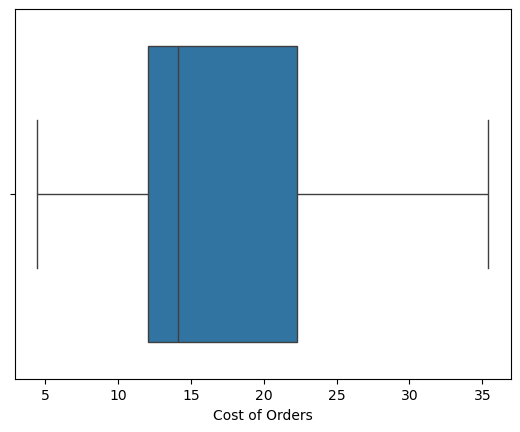

In [34]:
#Boxplot of order costs
sns.boxplot(x=df['cost_of_the_order'])
plt.xlabel('Cost of Orders')
plt.show()

In [35]:
#Describing the boxplot
Q1 = df['cost_of_the_order'].quantile(0.25)
Q3 = df['cost_of_the_order'].quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
df['cost_of_the_order'].describe()

Lower Outlier Fence = -3.246249999999998
Upper Outlier Fence = 37.62375


count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64

Observations:

Looking at order costs we see right skew, but no outliers..

**Day of Week**

In [36]:
#Count of orders by week v weekend
print((df["day_of_the_week"] == 'Weekend').sum(),'orders were placed on weekends')
print((df["day_of_the_week"] == 'Weekday').sum(),'orders were placed on weekdays')

1351 orders were placed on weekends
547 orders were placed on weekdays


Observations:

The majority of ordering occurs on weekends.

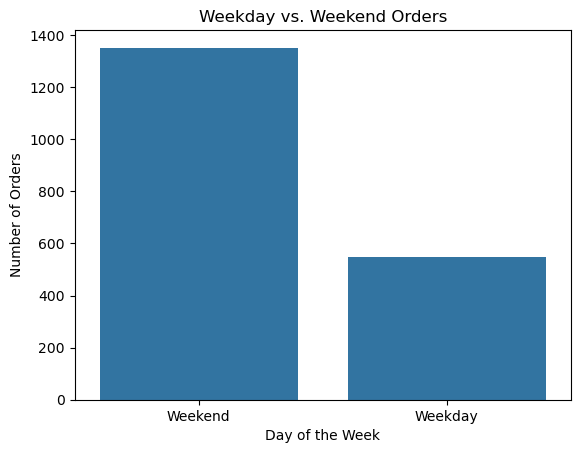

In [37]:
#Week v weekend countplot
sns.countplot(data=df, x="day_of_the_week")
plt.title('Weekday vs. Weekend Orders')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

**Rating**

In [38]:
#Rating values given
orders_per_rating = df['rating'].value_counts()
orders_per_rating.sort_values(ascending = True)

rating
3            188
4            386
5            588
Not given    736
Name: count, dtype: int64

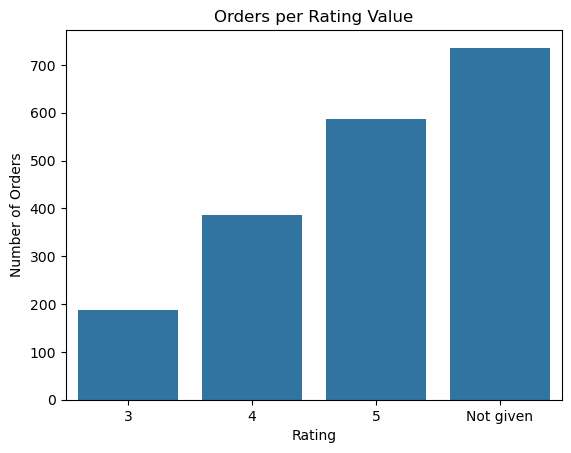

In [39]:
#Ratings Count histogram
sns.countplot(data=df, x="rating", order = sorted(df["rating"]))
plt.title('Orders per Rating Value')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

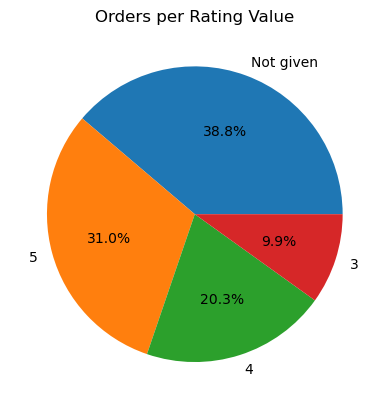

In [40]:
#Ratings Pie Chart
plt.pie(orders_per_rating.values, labels=orders_per_rating.index, autopct='%1.1f%%')
plt.title('Orders per Rating Value')
plt.show()

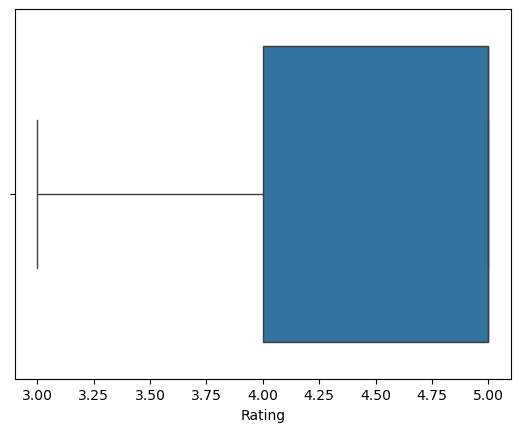

In [41]:
#Ratings boxplot
sns.boxplot(x=df_c['rating'])
plt.xlabel('Rating')
plt.show()

In [42]:
#Boxplot described
Q1 = df_c['rating'].quantile(0.25)
Q3 = df_c['rating'].quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
df_c['rating'].describe()

Lower Outlier Fence = 2.5
Upper Outlier Fence = 6.5


count      1162.0
mean     4.344234
std      0.741478
min           3.0
25%           4.0
50%           5.0
75%           5.0
max           5.0
Name: rating, dtype: Float64

736 orders (39%) were not rated at all

588 orders (31%) received a rating of 5

No order was rated less than 3: This could imply that customers opt to not rate lower quality orders that would rate less than 3.  It is also worth verifying there is no technical issue with the app not registering lower ratings.

Because we are unsure and can only make assumptions about the meaning and reasons behind these Not given ratings, I have chosen not to do any imputation at this time.

**Food Preparation Time**

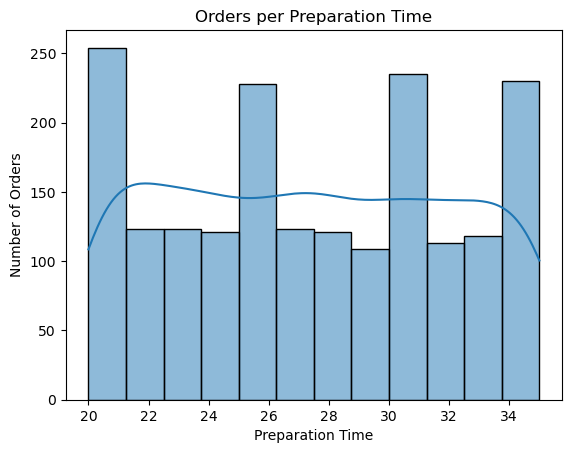

In [43]:
#Table representation isn't very helpful so I will jump directly to placing it in a countplot
sns.histplot(x="food_preparation_time", data=df, kde=True)
plt.title('Orders per Preparation Time')
plt.xlabel('Preparation Time')
plt.ylabel('Number of Orders')
plt.show()

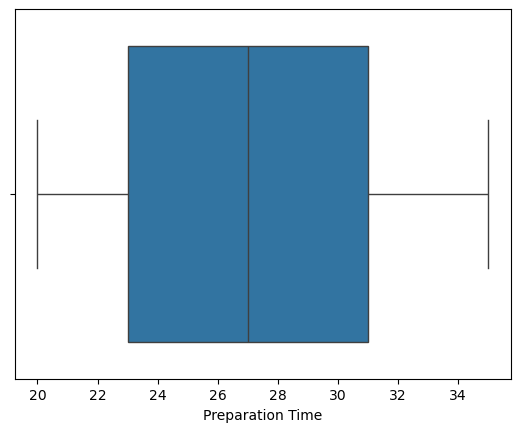

In [44]:
#Boxplot of preparation times
sns.boxplot(x=df['food_preparation_time'])
plt.xlabel('Preparation Time')
plt.show()

In [45]:
#Boxplot described
Q1 = df['food_preparation_time'].quantile(0.25)
Q3 = df['food_preparation_time'].quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
print('Skew = ',df['food_preparation_time'].skew(), '-> Right')

df['food_preparation_time'].describe()

Lower Outlier Fence = 11.0
Upper Outlier Fence = 43.0
Skew =  0.03646881825816354 -> Right


count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64

Observations:

Preparation time ranges from 20-35 min and appears fairly evenly distributed with a very slight skew right.

There are no outliers

The average food preparation time is 27.4 min

**Delivery Time**

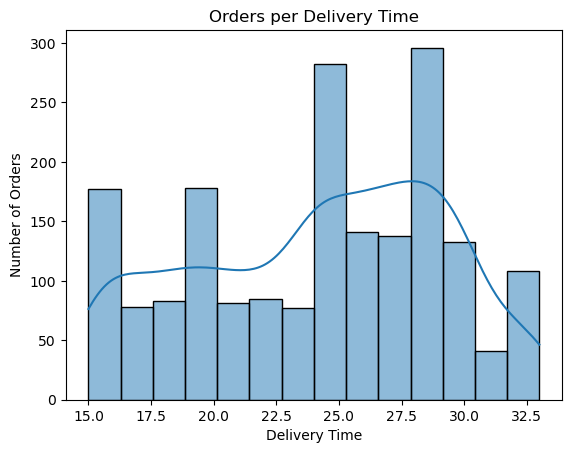

In [46]:
#Delivery Time Histplot:
sns.histplot(x="delivery_time", data=df, kde=True)
plt.title('Orders per Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Number of Orders')
plt.show()

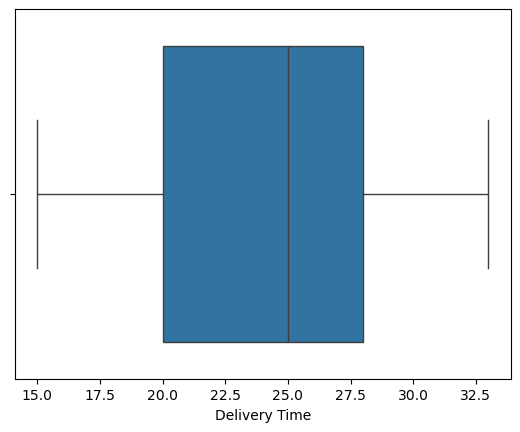

In [47]:
#Delivery Times Boxplot:
sns.boxplot(x=df['delivery_time'])
plt.xlabel('Delivery Time')
plt.show()

In [48]:
#Describing the boxplot:
Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)

df['delivery_time'].describe()

Lower Outlier Fence = 8.0
Upper Outlier Fence = 40.0


count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64

Observations:

Preparation time ranges from 15-33 min.

The increased number of orders between 24 min and 30 min prep time could imply that customers gravitate toward this time as a balance of speed and quality or it could imply that popular meals have a preparation time between 24 and 30 min.

**Total Time**

While looking at times it is a good idea to look at the total time from order to delivery (preparation time plus delivery time)

In [49]:
#Creating a copy of the Dataframe with an additional column for total time.
df_time = df_c.copy()
df_time['total_time'] = df_time['food_preparation_time'] + df_time['delivery_time']
df_time.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,<NA>,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,<NA>,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,49


In [50]:
df_time.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time,total_time
count,1.898000e+03,1898.000000,1898.000000,1162.0,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749,51.533720
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637,6.833603
min,1.476547e+06,1311.000000,4.470000,3.0,20.000000,15.000000,35.000000
25%,1.477021e+06,77787.750000,12.080000,4.0,23.000000,20.000000,47.000000
50%,1.477496e+06,128600.000000,14.140000,5.0,27.000000,25.000000,52.000000
75%,1.477970e+06,270525.000000,22.297500,5.0,31.000000,28.000000,56.000000
max,1.478444e+06,405334.000000,35.410000,5.0,35.000000,33.000000,68.000000


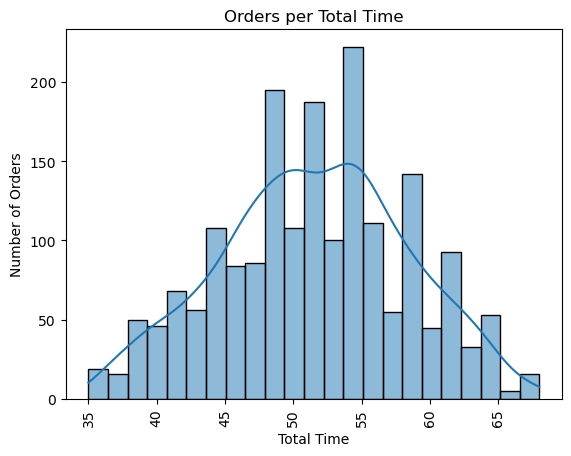

In [51]:
#Histplot of total time in minuts from order to delivery
sns.histplot(data=df_time, x="total_time", kde=True)
plt.title('Orders per Total Time')
plt.xlabel('Total Time')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.show()

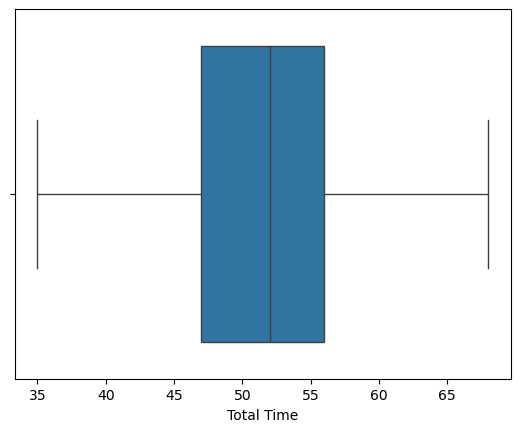

In [52]:
#Boxplot representation of total time order to delivery:
sns.boxplot(data= df_time, x='total_time')
plt.xlabel('Total Time')
plt.show()

In [53]:
#Describing the boxplot
Q1 = df_time['total_time'].quantile(0.25)
Q3 = df_time['total_time'].quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)

df_time['total_time'].describe()

Lower Outlier Fence = 33.5
Upper Outlier Fence = 69.5


count    1898.000000
mean       51.533720
std         6.833603
min        35.000000
25%        47.000000
50%        52.000000
75%        56.000000
max        68.000000
Name: total_time, dtype: float64

Observations:

We see that the total time from order to delivery ranges from 35 to 68 min with the average time being 51.5 min and a large number of orders falling between 46 and 58 min.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [54]:
# Write the code here
orders_per_restaurant = df['restaurant_name'].value_counts()
orders_per_restaurant.sort_values(ascending = False).head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
The top 5 restaurants for orders are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [55]:
# Write the code here
df_weekend_orders = df[df["day_of_the_week"] == 'Weekend']
df_weekend_orders['cuisine_type'].value_counts().sort_values(ascending=False).head()

cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64

In [56]:
df_weekend_orders['restaurant_name'].value_counts().sort_values(ascending=False).head()

restaurant_name
Shake Shack                  145
The Meatball Shop             95
Blue Ribbon Sushi             85
Blue Ribbon Fried Chicken     74
RedFarm Hudson                44
Name: count, dtype: int64

#### Observations:

American Food is most popular on weekends with 415 orders.

For Restaurants Shake Shack has the most weekend orders at 145.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [57]:
# Write the code here
(df[df['cost_of_the_order'] > 20].shape[0]/df.shape[0])*100

29.24130663856691

#### Observations:

29.2% of orders cost more than $20


### **Question 10**: What is the mean order delivery time? [1 mark]

In [58]:
# Write the code here

#In minutes:
df['delivery_time'].mean()
#Can also be seen in the .describe() above

np.float64(24.161749209694417)

In [59]:
#In minutes and seconds:
print(round(df['delivery_time'].mean()),':',round((df['delivery_time'].mean()-round(df['delivery_time'].mean()))*60))

24 : 10


#### Observations:

Mean delivery time is 24.16 min or 24 min, 10 seconds.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [60]:
# Write the code here
# Above we already have - order_count = df['customer_id'].value_counts()
order_count.sort_values(ascending = False).head()

customer_id
52832     13
47440     10
83287      9
250494     8
65009      7
Name: count, dtype: int64

#### Observations:

The top 5 customers in the time period measured are given above by customer ID and ordered 7 to 13 items each.


## Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset and provide observations. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


**Looking for Correlations**

Starting with a heat map of to identify any strong correlations in numerical data.

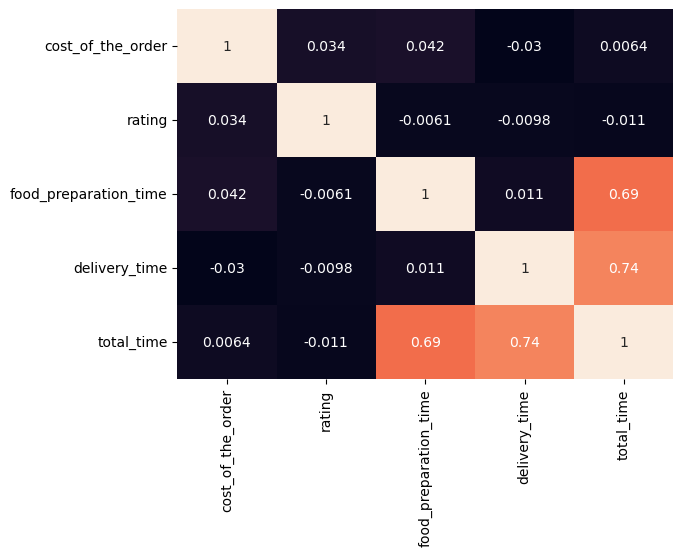

In [61]:
# Write the code here
#Heatmap of numerical variables:
sns.heatmap(data = df_time[['cost_of_the_order','rating','food_preparation_time','delivery_time','total_time']].corr(), annot=True, cbar=False)
plt.show()

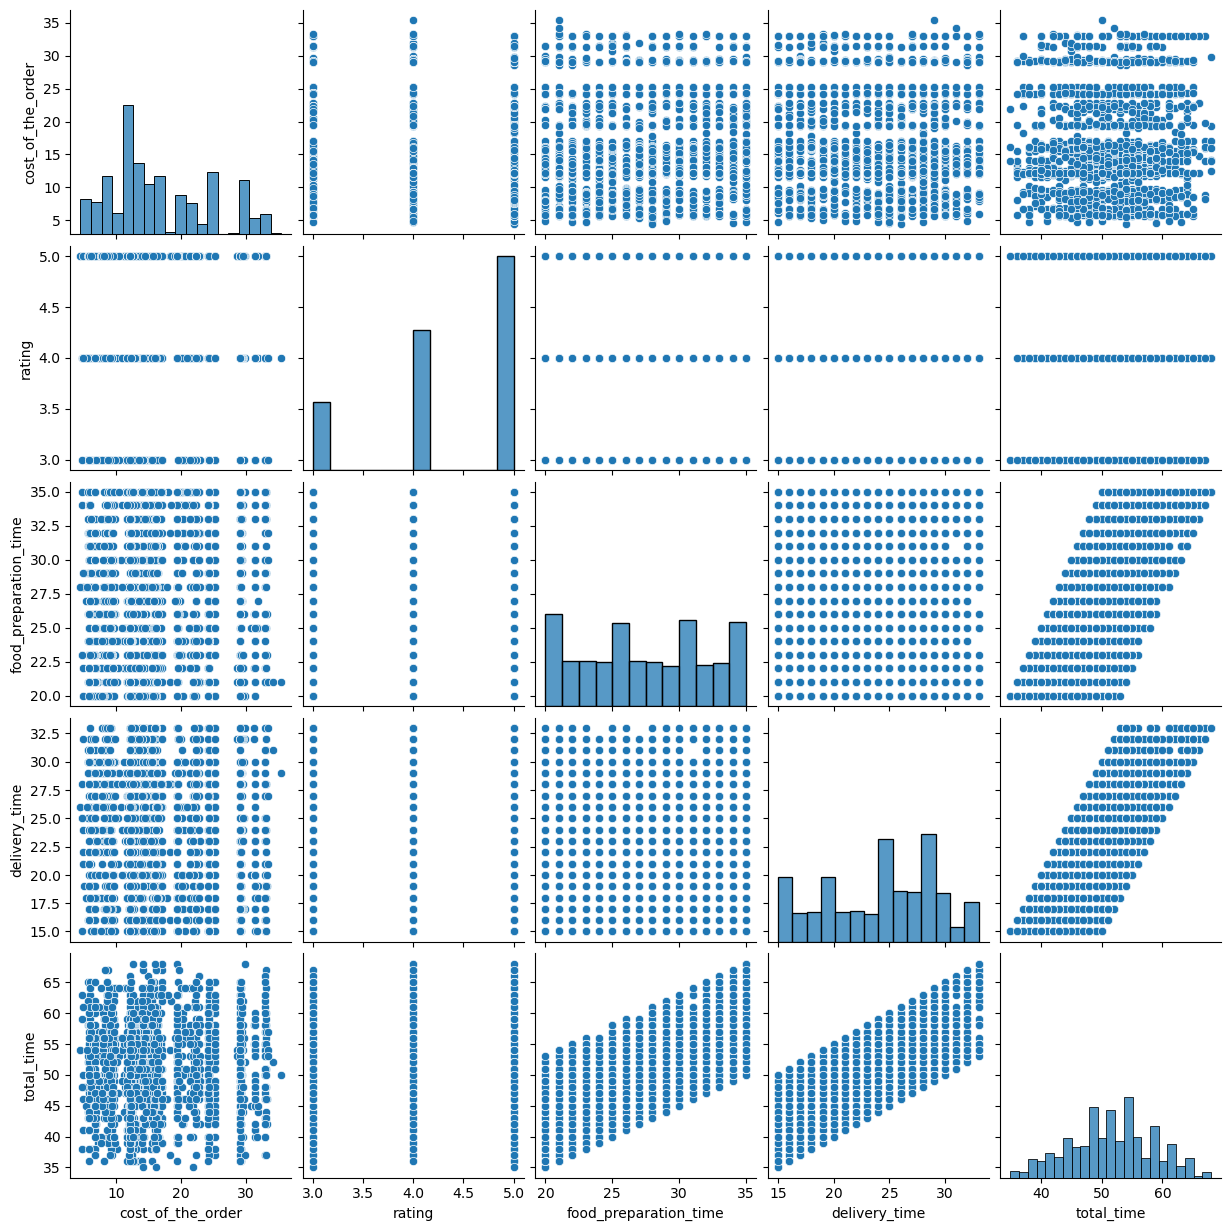

In [62]:
#Pairplot to visualize same information:
sns.pairplot(data=df_time[['cost_of_the_order','rating', 'food_preparation_time','delivery_time','total_time']])
plt.show()

Observations:

There do not appear to be any strong correlations between ratings, cost of orders, and time to prepare and deliver orders.

As one would expect there is a strong correlation between total time and the preparation and delivery times.

**Customer Trends**

Looking into individual customer behaviors, starting with repeat orders from the same restaurant.

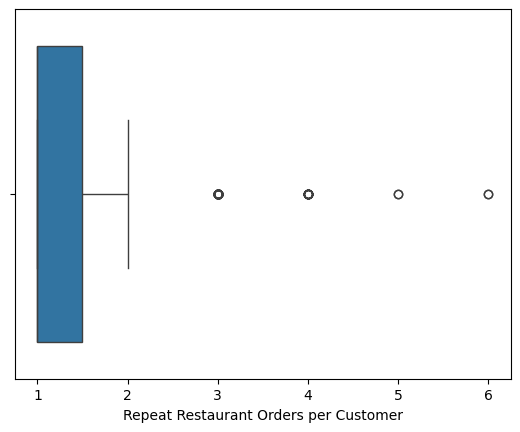

In [63]:
#Repeat Restaurant orders per customer:
sns.boxplot(x=df.groupby('customer_id')['restaurant_name'].value_counts())
plt.xlabel('Repeat Restaurant Orders per Customer')
plt.show()

In [64]:
Q1 = df.groupby('customer_id')['restaurant_name'].value_counts().quantile(0.25)
Q3 = df.groupby('customer_id')['restaurant_name'].value_counts().quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)

df.groupby('customer_id')['restaurant_name'].value_counts().describe()

Lower Outlier Fence = 0.25
Upper Outlier Fence = 2.25


count    1435.000000
mean        1.322648
std         0.644478
min         1.000000
25%         1.000000
50%         1.000000
75%         1.500000
max         6.000000
Name: count, dtype: float64

In [65]:
df.groupby('customer_id')['restaurant_name'].value_counts().sort_values(ascending = False).head()

customer_id  restaurant_name              
47440        Bareburger                       6
97991        Blue Ribbon Sushi Bar & Grill    6
84087        The Meatball Shop                5
97806        Shake Shack                      5
318451       Blue Ribbon Sushi                4
Name: count, dtype: int64

In [66]:
print((df.groupby('customer_id')['restaurant_name'].value_counts() > 1).sum(),'customers ordered more than once from the same restaurant')
print((df.groupby('customer_id')['restaurant_name'].value_counts() > 2).sum(),'customers were outliers with 3 or more orders from the same restaurant')

359 customers ordered more than once from the same restaurant
75 customers were outliers with 3 or more orders from the same restaurant


In [67]:
#Number of Repeat Customers per restaurant (how many customers visited more than 1 time)
repeat_customers = (df.groupby('restaurant_name')['customer_id'].value_counts() > 1).groupby('restaurant_name').sum().reset_index()

#Add avg rating column:
avg_ratings = df_c.groupby('restaurant_name')['rating'].mean().reset_index()
repeat_customers_rated = repeat_customers.merge(avg_ratings, on='restaurant_name',how='left')
repeat_customers_rated.sort_values(by='count',ascending=False)

,restaurant_name,count,rating
136,Shake Shack,37,4.278195
21,Blue Ribbon Sushi,31,4.219178
153,The Meatball Shop,24,4.511905
20,Blue Ribbon Fried Chicken,20,4.328125
121,RedFarm Broadway,13,4.243902
...,...,...,...
167,Wo Hop Restaurant,0,4.0
173,Zero Otto Nove,0,4.0
171,Yama 49,0,5.0
175,da Umberto,0,5.0


In [68]:
#Correlation between repeat customer count and average rating
repeat_customers_rated[['count', 'rating']].corr()

,count,rating
count,1.000000,-0.030175
rating,-0.030175,1.000000


Observations:
Weak correlation between repeat customers and average rating of restaurants.

In [69]:
#Number of Repeat orders per restaurant (total number of orders from people who ordered more than once)
repeat_orders = df.groupby('restaurant_name')['customer_id'].value_counts().loc[lambda x: x > 1].groupby('restaurant_name').sum().reset_index()

#Merge average rating column:
repeat_orders_rated = repeat_orders.merge(avg_ratings, on='restaurant_name',how='left')
repeat_orders_rated.sort_values(by='count',ascending=False).head()

,restaurant_name,count,rating
67,Shake Shack,86,4.278195
10,Blue Ribbon Sushi,75,4.219178
77,The Meatball Shop,54,4.511905
9,Blue Ribbon Fried Chicken,48,4.328125
11,Blue Ribbon Sushi Bar & Grill,31,4.590909


In [70]:
#Correlation between repeat ordering and average rating
repeat_orders_rated[['count', 'rating']].corr()

,count,rating
count,1.000000,-0.063962
rating,-0.063962,1.000000


Observations:
Again weak correlation between repeat orders and average rating of restaurants.

Observations:

We see that the majority of customers ordered less than 2 meals from the same restaurant, with anything above 2 being an outlier.  The max someone ordered from the same restaurant was 6 times.  Breaking this out by customer ID we could use this information for targeted advertising, loyalty discounts, etc.

We can also see that of 416 customers who ordered more than once, 359 had repeat orders from the same restaurant.

We also see that Blue Ribbon Sushi Bar & Gril and Bareburger have the two most loyal customers with 6 orders each, but Shake shack has the most repeat customers (37 people ordered more than once for a total of 86 orders)

We can do the same analysis to for cuisine type to identify customer affinity for types of food:

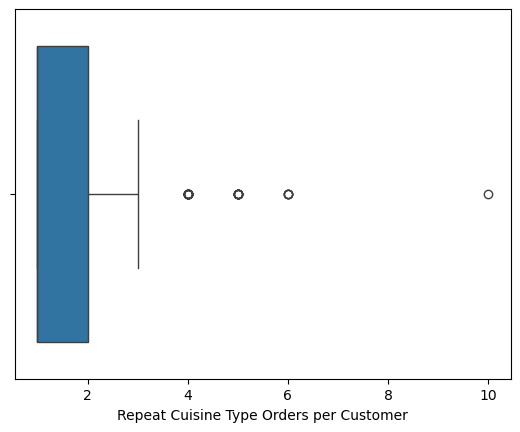

In [71]:
#Repeat ordering by cuisine type
sns.boxplot(x=df.groupby('customer_id')['cuisine_type'].value_counts())
plt.xlabel('Repeat Cuisine Type Orders per Customer')
plt.show()

In [72]:
Q1 = df.groupby('customer_id')['cuisine_type'].value_counts().quantile(0.25)
Q3 = df.groupby('customer_id')['cuisine_type'].value_counts().quantile(0.75)
IQR = Q3 - Q1

print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
print('Upper Outlier Fence =', Q3 + 1.5 * IQR)

df.groupby('customer_id')['cuisine_type'].value_counts().describe()

Lower Outlier Fence = -0.5
Upper Outlier Fence = 3.5


count    1371.000000
mean        1.384391
std         0.781364
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: count, dtype: float64

In [73]:
#Number of times customer each customer ordered each type of cusine:
df.groupby('customer_id')['cuisine_type'].value_counts().sort_values(ascending = False).head()

customer_id  cuisine_type
47440        American        10
97991        Japanese         6
115213       Indian           6
97079        Japanese         6
250494       American         6
Name: count, dtype: int64

Observations:

The above is not very helpful for trending, but can be used for advertising purposes.

In [74]:
#Number of Repeat Customers per Cuisine Type
repeat_cust_cuisine = (df.groupby('cuisine_type')['customer_id'].value_counts() > 1).groupby('cuisine_type').sum().reset_index()

#Add ratings column
avg_cuisine_ratings = df_c.groupby('cuisine_type')['rating'].mean().reset_index()
repeat_cust_cuisine_rated = repeat_cust_cuisine.merge(avg_cuisine_ratings, on='cuisine_type', how='left')
repeat_cust_cuisine_rated.head()

,cuisine_type,count,rating
0,American,113,4.298913
1,Chinese,40,4.338346
2,French,4,4.3
3,Indian,14,4.54
4,Italian,53,4.360465


In [75]:
#Correlation between repeat ordering and average rating
repeat_cust_cuisine_rated[['count', 'rating']].corr()

,count,rating
count,1.000000,-0.038874
rating,-0.038874,1.000000


In [76]:
#Number of Repeat orders per Cuisine Type
repeat_cuisine_orders = df.groupby('restaurant_name')['cuisine_type'].value_counts().loc[lambda x: x > 1].groupby('cuisine_type').sum().reset_index()

#Adding ratings column
repeat_cuisine_orders_rated = repeat_cuisine_orders.merge(avg_cuisine_ratings, on='cuisine_type', how='left')
repeat_cuisine_orders_rated.head()

,cuisine_type,count,rating
0,American,575,4.298913
1,Chinese,210,4.338346
2,French,18,4.3
3,Indian,69,4.54
4,Italian,285,4.360465


In [77]:
#Correlation between repeat ordering and average rating
repeat_cuisine_orders_rated[['count', 'rating']].corr()

,count,rating
count,1.000000,-0.041059
rating,-0.041059,1.000000


Observations:

Again we see very little correlation between rating and repeat behavior.


Observations:

American food has the most repeat orders with 113 customers ordering more than once for a total of 575 orders.

Again, the customer IDs above that are associated with repeat Cuisine Type orders could be used for targeted advertising.  If we know someone likes a particular Cuisine Type we can advertise other restaurants that would likely appeal to them.

Looking at Customer Spending Habits:

In [78]:
#Total spend on orders and average spend per order by customer ID:
customer_spend = df.groupby('customer_id')['cost_of_the_order'].agg(total_spend='sum',avg_spend='mean')
customer_spend.head()

,total_spend,avg_spend
customer_id,,
1311,16.10,16.100
5139,22.26,22.260
5444,20.18,20.180
5693,8.30,8.300
6987,42.01,21.005


In [79]:
customer_spend.describe()

,total_spend,avg_spend
count,1200.000000,1200.000000
mean,26.095683,16.456487
std,20.796383,6.591341
min,4.750000,4.750000
25%,12.660000,12.130000
50%,20.695000,15.040000
75%,31.430000,20.785000
max,225.800000,33.320000


In [80]:
customer_spend.corr()

,total_spend,avg_spend
total_spend,1.00000,0.40963
avg_spend,0.40963,1.00000


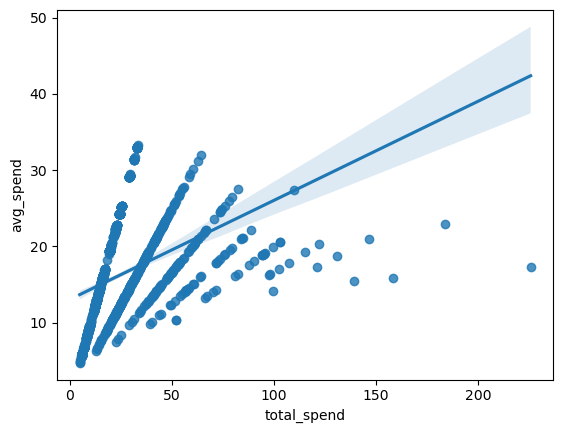

In [81]:
#Visualizing the relationship between average and total spend
sns.regplot(x='total_spend',y='avg_spend',data=customer_spend)
plt.show()

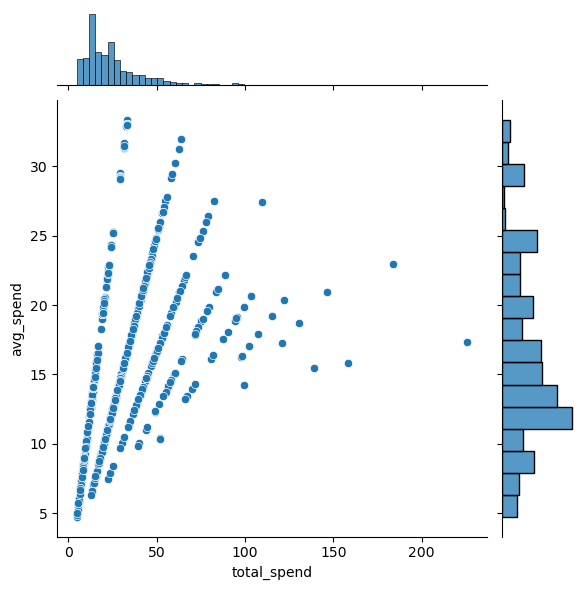

In [82]:
sns.jointplot(x='total_spend',y='avg_spend',data=customer_spend)
plt.show()

Observations:

As expected there is a moderate correlation between a customer's average and total spend.

The max total spent by a single customer in the measured period was 225.80 and the minimum was 4.75.  75% of customers spend 20.79 or less per order on average.

Again customer level spend data can be used for targeted advertising.  Average spend per order can be used to identify restaurants in the customer's desired price range.  Total spend can be trended over time to identify spending habit changes, advertising impacts, etc.

**Restaurant Trends**

In [83]:
#Total Spend and Average spend per order for each restaurant
restaurant_cost = df_time.groupby('restaurant_name')['cost_of_the_order'].agg(total_spend='sum',avg_spend='mean')
restaurant_cost.sort_values(by='total_spend',ascending=False).head()

,total_spend,avg_spend
restaurant_name,,
Shake Shack,3579.53,16.344886
The Meatball Shop,2145.21,16.251591
Blue Ribbon Sushi,1903.95,15.999580
Blue Ribbon Fried Chicken,1662.29,17.315521
Parm,1112.76,16.364118


Observations:

Shake Shack has the highest total spent on their food with 3579.53

Kambi Ramen House on the other hand has the highest average spend with only one order at 32.93

In [84]:
#Creating an average rating column
restaurant_rating = df_time.groupby('restaurant_name')['rating'].mean()
restaurant_cost_rating = restaurant_cost.merge(restaurant_rating, on='restaurant_name',how='left')

#Creating an average total time column
restaurant_time = df_time.groupby('restaurant_name')['total_time'].mean()
restaurant_cost_rating_time = restaurant_cost_rating.merge(restaurant_time, on='restaurant_name',how='left')

restaurant_cost_rating_time.sort_values(by='total_spend',ascending=False).head()

,total_spend,avg_spend,rating,total_time
restaurant_name,,,,
Shake Shack,3579.53,16.344886,4.278195,52.607306
The Meatball Shop,2145.21,16.251591,4.511905,51.424242
Blue Ribbon Sushi,1903.95,15.999580,4.219178,51.865546
Blue Ribbon Fried Chicken,1662.29,17.315521,4.328125,51.343750
Parm,1112.76,16.364118,4.128205,52.808824


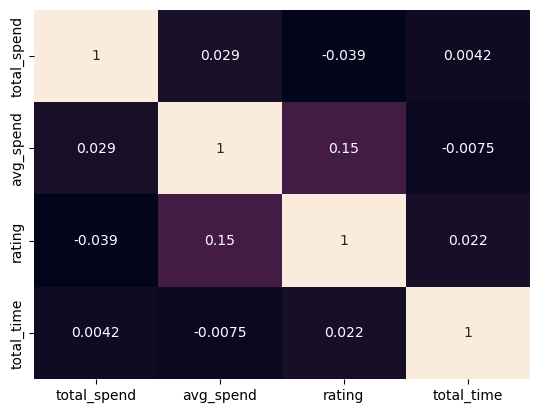

In [85]:
#Heatmap of total spend, average spend, average rating, and average total time of order per restaurant
sns.heatmap(restaurant_cost_rating_time.corr(), annot=True, cbar=False)
plt.show()

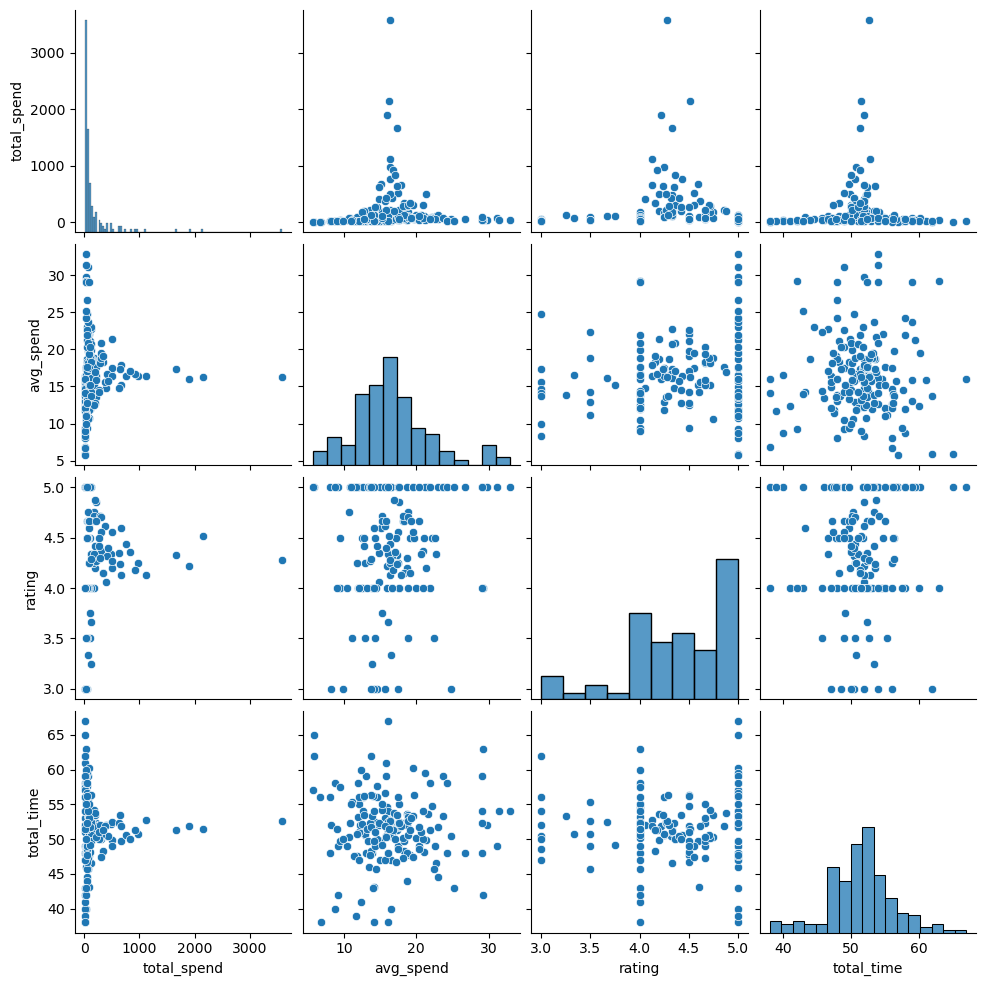

In [86]:
#Same info in a pairplot
sns.pairplot(data=restaurant_cost_rating_time)
plt.show()

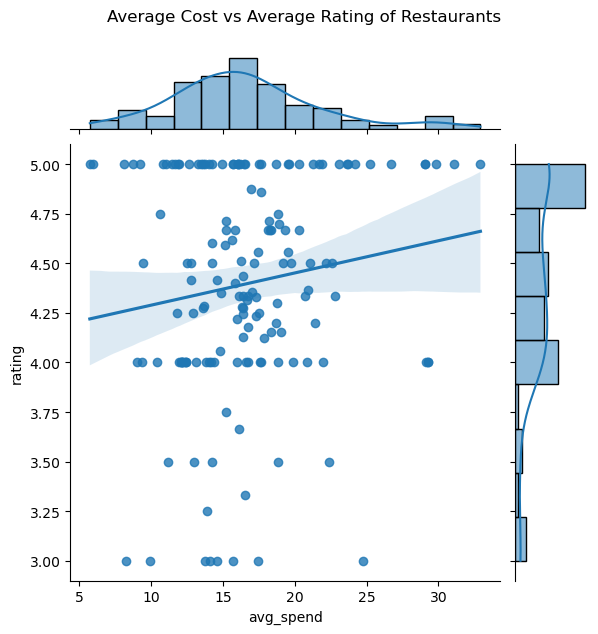

In [87]:
#Closer look comparing average spend on a restaurant and the restaurant's average rating value
spend_v_rating_rest_graph = sns.jointplot(data=restaurant_cost_rating_time, x='avg_spend', y='rating', kind='reg')
spend_v_rating_rest_graph.fig.suptitle('Average Cost vs Average Rating of Restaurants', y=1.05)
plt.show()

In [88]:
restaurant_cost_rating_time.describe()

,total_spend,avg_spend,rating,total_time
count,178.000000,178.000000,156.0,178.000000
mean,175.925955,16.538101,4.397807,51.460162
std,394.615994,5.232864,0.552062,4.851101
min,5.720000,5.720000,3.0,38.000000
25%,23.840000,13.159167,4.0,49.000000
50%,54.615000,16.060000,4.425725,51.650000
75%,124.842500,18.851667,5.0,54.000000
max,3579.530000,32.930000,5.0,67.000000


Observations:

There is little correlation between total time of order, rating, average spend per order and total spend on a restaurant.

At best we have a very weak positive correlation between average spend on a restaurant and that restaurant's average rating.

Let's look further into average ratings and not rated restaurants:

In [89]:
#Average Ratings by Restaurant
#Devined above as: avg_ratings = df_c.groupby('restaurant_name')['rating'].mean().reset_index()

#Restaurants with less than 4 stars - List hidden for flow
less_than_four_star = avg_ratings[avg_ratings['rating'] < 4].reset_index()
less_than_four_star.shape

(17, 3)

In [90]:
#4 Star and Up restaurants
four_to_five_star = avg_ratings[avg_ratings['rating'] >= 4].reset_index()
four_to_five_star.shape

(139, 3)

In [91]:
#Restaurants that have never been rated
not_rated_restaurants = avg_ratings[avg_ratings['rating'].isna()].reset_index(drop=True)
not_rated_restaurants.shape

(22, 2)

Observations:

Here we can see 139 Restaurants with an average rating of 4.0 and above, 17 with ratings less than 4 and 22 that have never been rated.

It may be beneficial send reminders to rate these restaurants that have never been rated following orders in order to be able to assess their quality.

Let's see if we can find a trend among these 22 restaurants that have never been rated:

In [92]:
#Adding average cost to the Not rated restaurants df:
not_rated_cost = not_rated_restaurants.merge(restaurant_cost, on='restaurant_name',how='left')

#Adding count of repeat customers Not rated restaurants df:
not_rated_cost_repeat = not_rated_cost.merge(repeat_customers, on='restaurant_name',how='left')

#Making a df of the average total time from order to delivery for each restaurant.
avg_restaurant_time = df_time.groupby('restaurant_name')['total_time'].mean().reset_index()

#Adding total time to the not rated restaurants df:
not_rated_cost_repeat_time = not_rated_cost_repeat.merge(avg_restaurant_time, on='restaurant_name',how='left')

#Display Head
not_rated_cost_repeat_time.head()

,restaurant_name,rating,total_spend,avg_spend,count,total_time
0,Alidoro,<NA>,12.61,12.610,0,56.0
1,Aurora,<NA>,28.67,14.335,1,52.5
2,Big Wong Restaurant _¤¾Ñ¼,<NA>,5.92,5.920,0,62.0
3,Bistango,<NA>,46.08,23.040,0,44.5
4,Coppola's East,<NA>,13.05,13.050,0,48.0


In [93]:
#Description of not rated restaurant stats:
not_rated_cost_repeat_time.describe()

,rating,total_spend,avg_spend,count,total_time
count,0.0,22.000000,22.000000,22.000000,22.000000
mean,<NA>,21.365455,15.317652,0.136364,50.931818
std,<NA>,13.531169,6.956170,0.351250,6.818055
min,<NA>,5.920000,5.920000,0.000000,38.000000
25%,<NA>,10.067500,10.067500,0.000000,48.000000
50%,<NA>,15.860000,14.442500,0.000000,50.250000
75%,<NA>,30.847500,18.071250,0.000000,56.000000
max,<NA>,46.080000,31.430000,1.000000,62.000000


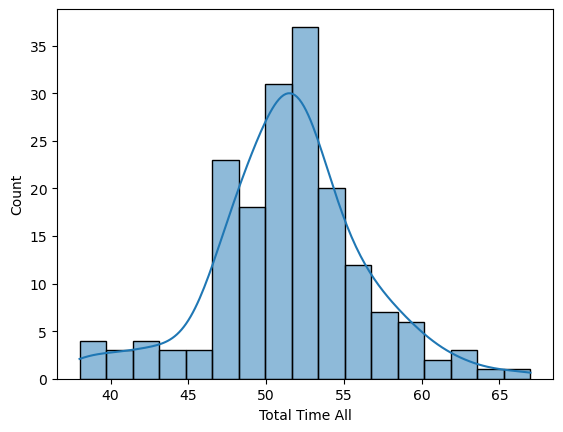

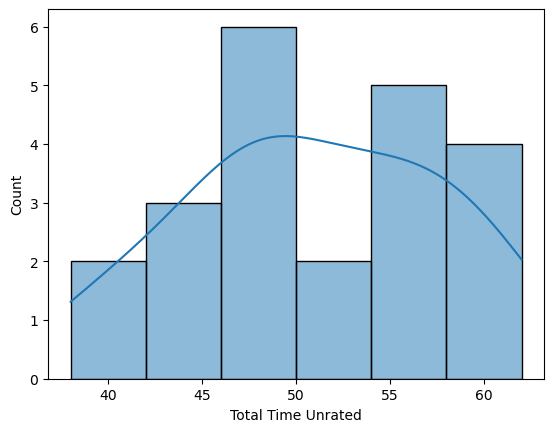

In [94]:
#Comparing Average Total time to prepare and deliver of not rated restaurants to all restaurants

#Average Total Time for all Restaurants
sns.histplot(data=restaurant_cost_rating_time, x='total_time', kde=True)
plt.xlabel('Total Time All')
plt.show()

#Average Total Time for unrated Restaurants
sns.histplot(data=not_rated_cost_repeat_time, x='total_time', kde=True)
plt.xlabel('Total Time Unrated')
plt.show()

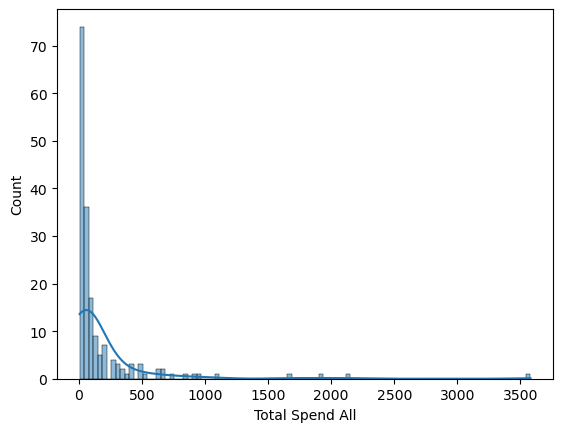

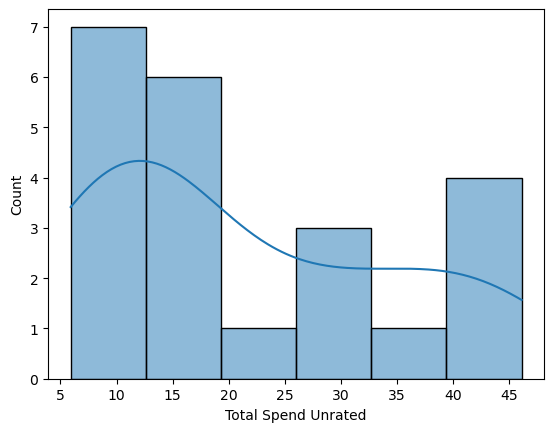

In [95]:
#Comparing Total spend of not rated restaurants to all restaurants

#Total spend for all Restaurants
sns.histplot(data=restaurant_cost_rating_time, x='total_spend', kde=True)
plt.xlabel('Total Spend All')
plt.show()

#Total spend for unrated Restaurants
sns.histplot(data=not_rated_cost_repeat_time, x='total_spend', kde=True)
plt.xlabel('Total Spend Unrated')
plt.show()

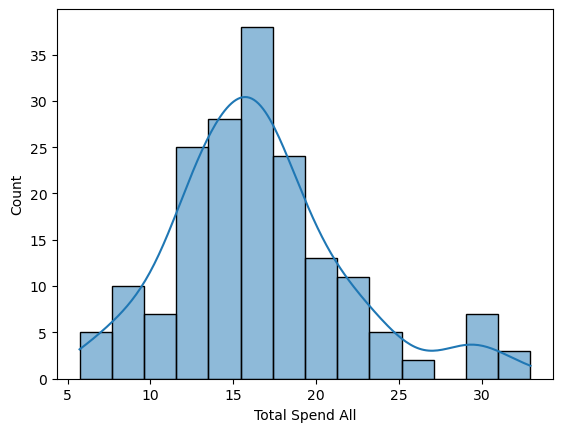

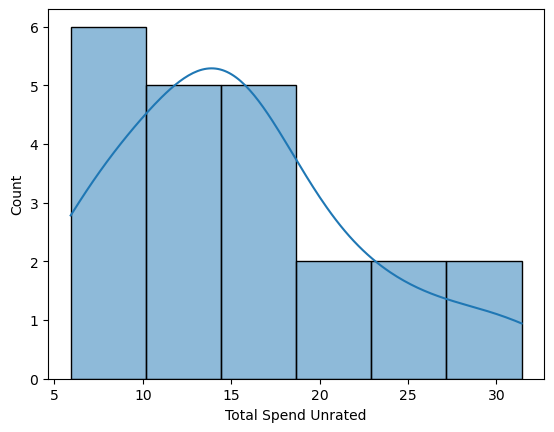

In [96]:
#Comparing Average spend per order of not rated restaurants to all restaurants

#Average spend per order for all Restaurants
sns.histplot(data=restaurant_cost_rating_time, x='avg_spend', kde=True)
plt.xlabel('Total Spend All')
plt.show()

#Total spend for unrated Restaurants
sns.histplot(data=not_rated_cost_repeat_time, x='avg_spend', kde=True)
plt.xlabel('Total Spend Unrated')
plt.show()

Observations:

Comparing with restaurant_cost above, we see that the average spent per meal at the unrated restaurants is fairly in line with other restaurants, but the average total spent is far lower due to a lack of repeat customers (only 3 of the 22 unrated restaurants had a repeat customer).  

Looking into the delivery time the range and average for the unrated restaurants is very similar to that of all restaurants.  This implies that if a lack of rating means poor satisfaction, it is not due to delivery times.

All of this together (lack of repeat customers and normal service times) supports the hypothesis that Not rated restaurants may have poor quality.

Now I want to see if cuisine type impacts this lack of rating:

In [97]:
#First check that each restaurant has only one cuisine type.
df.groupby('restaurant_name')['cuisine_type'].nunique().sort_values(ascending=False).head()

restaurant_name
The Meatball Shop    2
'wichcraft           1
5 Napkin Burger      1
67 Burger            1
Alidoro              1
Name: cuisine_type, dtype: int64

Observations:

Here we see the only restaurant with more than one type is The Meatball Shop and this does not impact our set of unrated restaurants.

In [98]:
# Count of Unrated Restaurants by cuisine type:
not_rated_cuisine_type = not_rated_cost_repeat_time.merge(df[['restaurant_name', 'cuisine_type']].drop_duplicates(), on='restaurant_name', how='left')
not_rated_cuisine_type['cuisine_type'].value_counts()

cuisine_type
Italian     11
American     3
Thai         3
Chinese      2
Mexican      1
Korean       1
Japanese     1
Name: count, dtype: int64

In [99]:
#Normalized by dividing by total number of orders of each cuisine type:
not_rated_cuisine_type = not_rated_cost_repeat_time.merge(df[['restaurant_name', 'cuisine_type']].drop_duplicates(), on='restaurant_name', how='left')
not_rated_cuisine_type['cuisine_type'].value_counts()/df['cuisine_type'].value_counts()*100

cuisine_type
American           0.513699
Chinese            0.930233
French                  NaN
Indian                  NaN
Italian            3.691275
Japanese           0.212766
Korean             7.692308
Mediterranean           NaN
Mexican            1.298701
Middle Eastern          NaN
Southern                NaN
Spanish                 NaN
Thai              15.789474
Vietnamese              NaN
Name: count, dtype: float64

Observations:

Most unrated restaurants serve Italian cuisine, but these only make up 3.7% of total Italian food orders.

Unrated Korean restaurants make up 7.7% of total Korean cuisine orders and unrated Thai restaurants make up 15.8% of total Thai cuisine orders.

**Cuisine Trends**

With this let's look at other trends by cuisine types:

In [100]:
#making a df of total spend and average spend per order on each cuisine type:
cuisine_cost = df_time.groupby('cuisine_type')['cost_of_the_order'].agg(total_spend='sum',avg_spend='mean')

#Creating an average rating column
cuisine_rating = df_time.groupby('cuisine_type')['rating'].mean()
cuisine_cost_rating = cuisine_cost.merge(cuisine_rating, on='cuisine_type',how='left')

#Creating an average total time column
cuisine_time = df_time.groupby('cuisine_type')['total_time'].mean()
cuisine_cost_rating_time = cuisine_cost_rating.merge(cuisine_time, on='cuisine_type',how='left')

cuisine_cost_rating_time.sort_values(by='total_spend',ascending=False).head()

,total_spend,avg_spend,rating,total_time
cuisine_type,,,,
American,9530.78,16.319829,4.298913,51.633562
Japanese,7663.13,16.304532,4.373626,51.642553
Italian,4892.77,16.418691,4.360465,52.050336
Chinese,3505.62,16.305209,4.338346,51.367442
Mexican,1303.85,16.933117,4.416667,51.116883


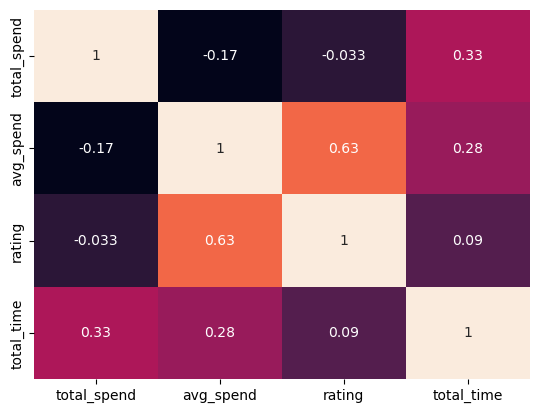

In [101]:
#Showing this Cuisine type average data in heat map
sns.heatmap(cuisine_cost_rating_time.corr(), annot=True, cbar=False)
plt.show()

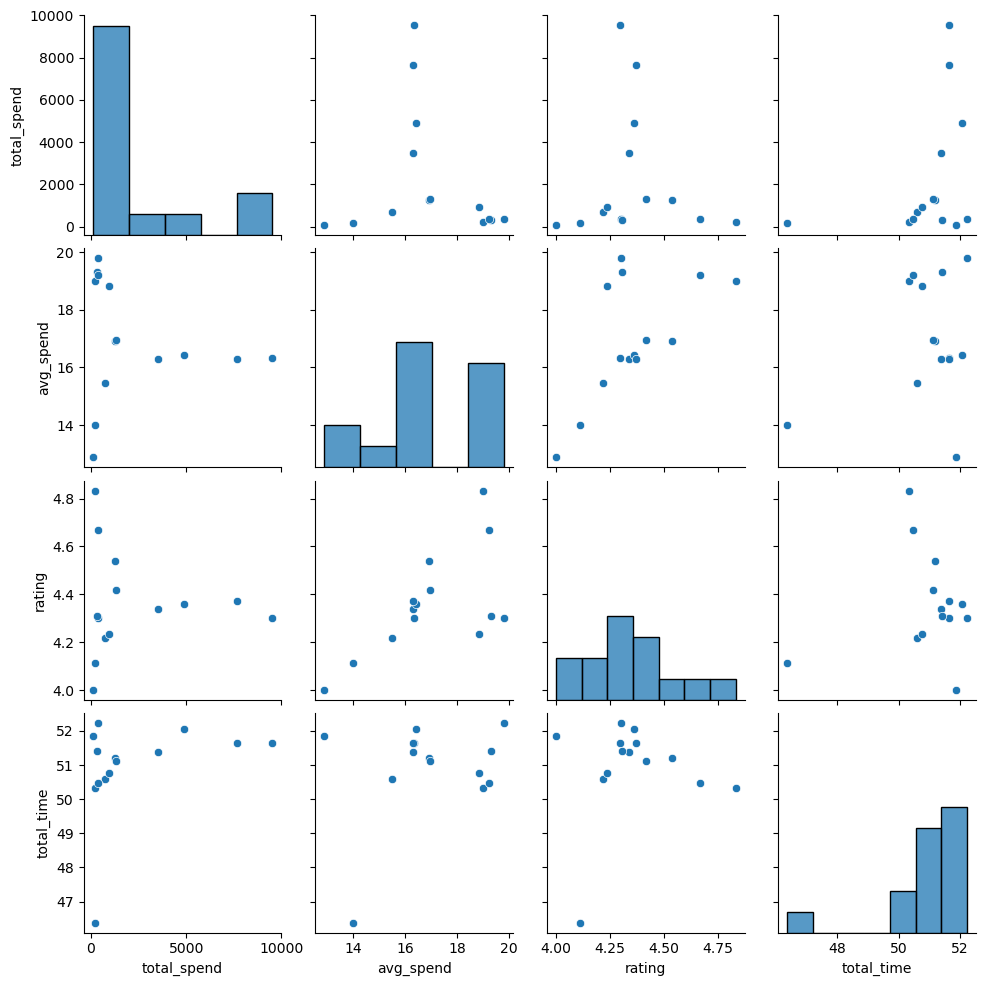

In [102]:
sns.pairplot(data=cuisine_cost_rating_time)
plt.show()

Observations:

American cuisine took in the most in total spend.

French cuisine saw the highest spend per order, but was in the bottom 5 for total spend.

We can also see that there is a strong correlation between the average spend per order on a cuisine type and average rating of a cuisine type, but this does not carry over to the total spend nor does it carry over to restaurant level trends or order level trends and therefore is unlikely to give useful insights.

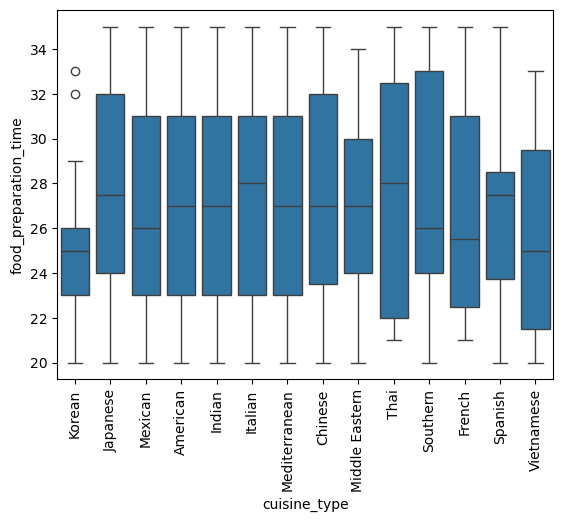

In [103]:
#Comparing preparation times of different Cuisine Types
sns.boxplot(data=df_time, x='cuisine_type', y='food_preparation_time')
plt.xticks(rotation=90)
plt.show()

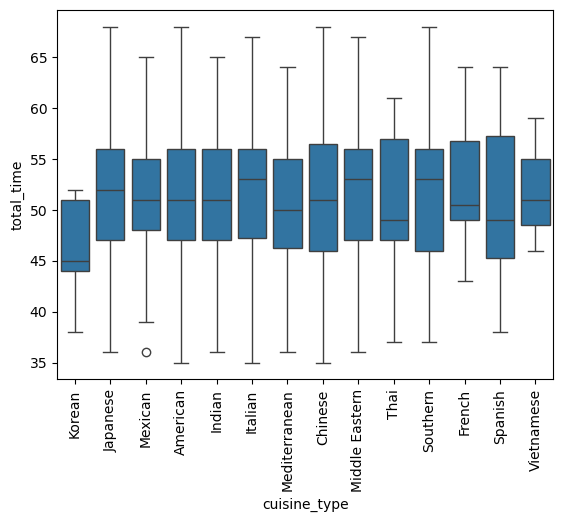

In [104]:
#Type v Total Time (Prep plus delivery)
sns.boxplot(data=df_time, x='cuisine_type', y='total_time')
plt.xticks(rotation=90)
plt.show()

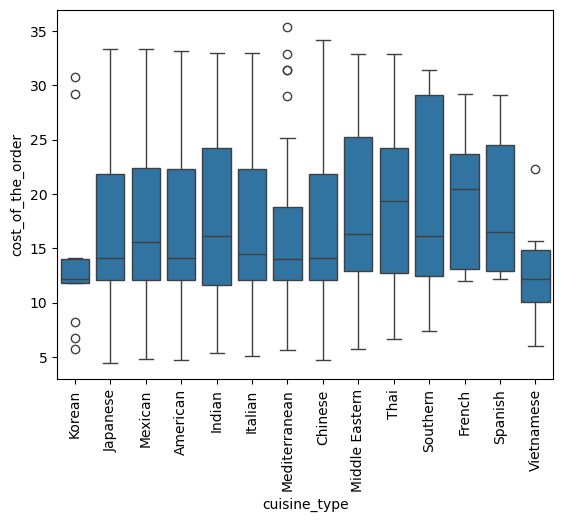

In [105]:
#Cuisine Type vs. Cost of order
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=90)
plt.show()

Observations:

Korean food has the lowest average and maximum times for both preparation time and total time.

Korean and Thai are the least expensive cuisine types overall.

**Cost Trends**

In [106]:
#Average order cost during week v. weekend
cost_by_day = df_time.groupby('day_of_the_week')['cost_of_the_order'].mean().reset_index()
cost_by_day

,day_of_the_week,cost_of_the_order
0,Weekday,16.311188
1,Weekend,16.574833


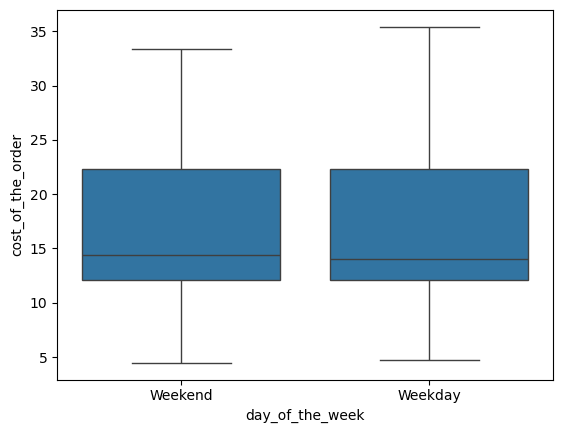

In [107]:
#Order cost by day of week
sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order')
plt.show()

In [108]:
#Total spent during week v. weekend
total_spend_by_day = df_time.groupby('day_of_the_week')['cost_of_the_order'].sum()
total_spend_by_day

day_of_the_week
Weekday     8922.22
Weekend    22392.60
Name: cost_of_the_order, dtype: float64

In [109]:
print('The total weekend spend is',total_spend_by_day['Weekend'] - total_spend_by_day['Weekday'],'more than the weekday spend')
print(((total_spend_by_day['Weekend'] - total_spend_by_day['Weekday'])/total_spend_by_day['Weekday'])*100,'%')

The total weekend spend is 13470.38 more than the weekday spend
150.9756540412588 %


Observations:

Customers appear to spend ~26 cents more per order on weekends

This coupled with the increased rate of ordering on weekends that we observed above leads to a significantly higher total spend on weekends vs weekdays

**Day of Week Trends**

In [110]:
#Average rating by day of week
rating_by_day = df_time.groupby('day_of_the_week')['rating'].mean().reset_index()

#adding column for average prep time:
prep_by_day = df_time.groupby('day_of_the_week')['food_preparation_time'].mean().reset_index()
rating_prep_by_day = rating_by_day.merge(prep_by_day, on='day_of_the_week',how='left')

#adding column for average delivery time
delivery_by_day = df_time.groupby('day_of_the_week')['delivery_time'].mean().reset_index()
rating_prep_delivery_by_day = rating_prep_by_day.merge(delivery_by_day, on='day_of_the_week', how='left')

#adding total time column
total_by_day = df_time.groupby('day_of_the_week')['total_time'].mean().reset_index()
rating_prep_delivery_total_by_day = rating_prep_delivery_by_day.merge(total_by_day, on='day_of_the_week', how='left')
rating_prep_delivery_total_by_day

,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,Weekday,4.308824,27.212066,28.340037,55.552102
1,Weekend,4.358881,27.436714,22.470022,49.906736


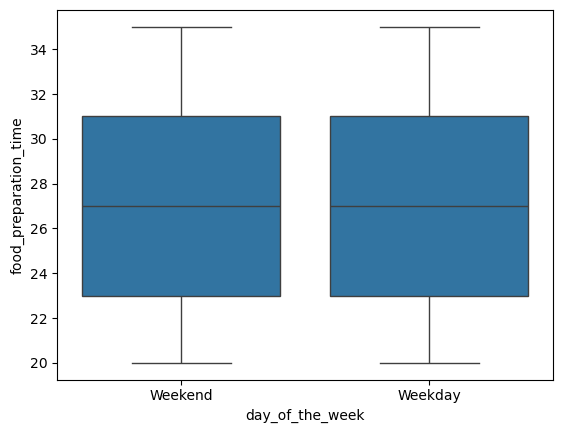

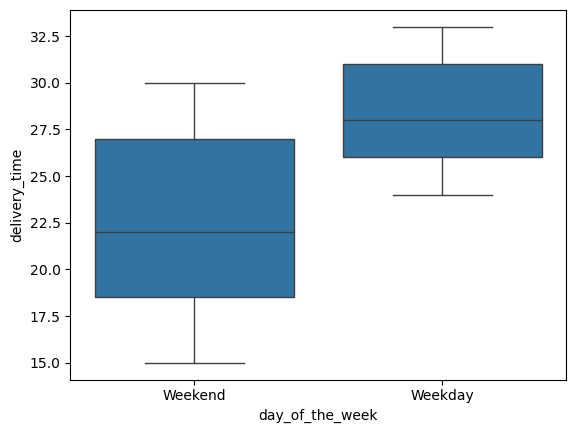

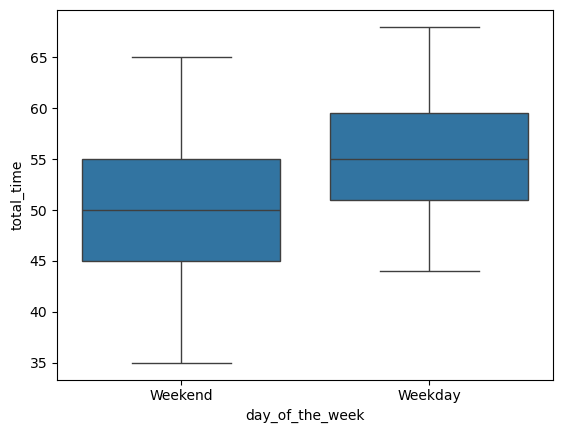

In [111]:
#Boxplots showing Prep, delivery, and total time by day of week:
sns.boxplot(data=df_time, x='day_of_the_week', y='food_preparation_time')
plt.show()
sns.boxplot(data=df_time, x='day_of_the_week', y='delivery_time')
plt.show()
sns.boxplot(data=df_time, x='day_of_the_week', y='total_time')
plt.show()

Observations:

Very little difference in average order rating and preparation time on weekends vs. weekdays.

Delivery time (and total time) is almost 6 minuts slower on average for weekdays vs. weekends.

This may contribute to the small .05 difference in rating between weekdays and weekends

Looking into Cuisine Preference by day of week:

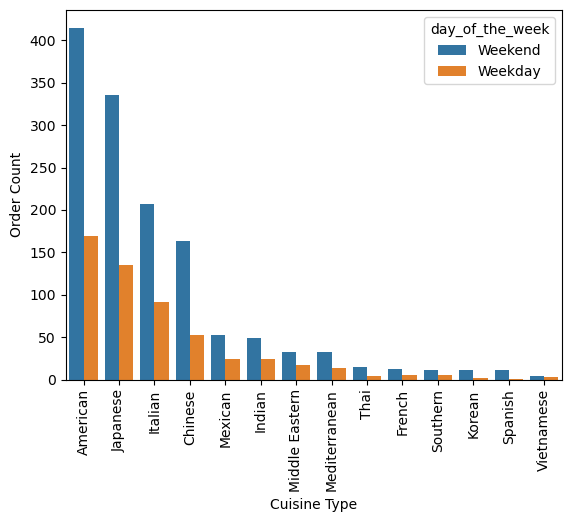

In [112]:
#Orders per Cuisine Type by day of week:
cuisine_order = df['cuisine_type'].value_counts().index
sns.countplot(data=df, x='cuisine_type', hue='day_of_the_week', order=cuisine_order)
plt.xlabel('Cuisine Type')
plt.ylabel('Order Count')
plt.xticks(rotation=90)
plt.show()

Observations:

There appears to be more ordering of all food types and prices on the weekend, but proportionally ordering behavior appears very similar.

**Rating Trends**

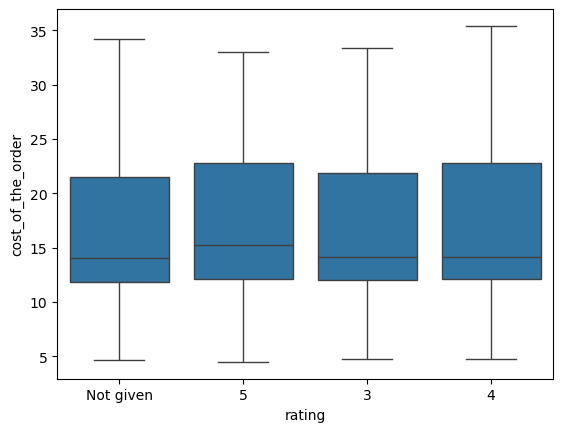

In [113]:
#Cost of order for each rating
sns.boxplot(data=df, x='rating', y='cost_of_the_order')
plt.show()

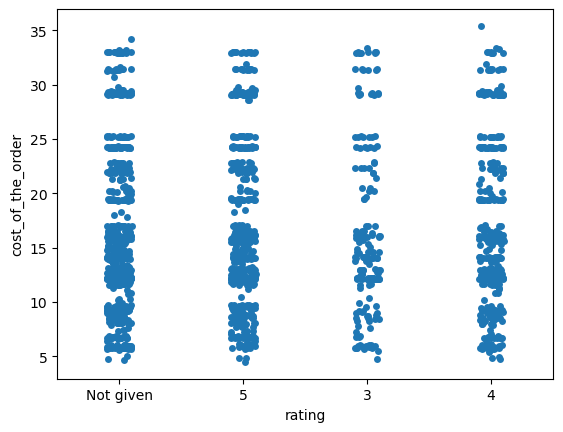

In [114]:
sns.stripplot(data=df, x='rating', y='cost_of_the_order')
plt.show()

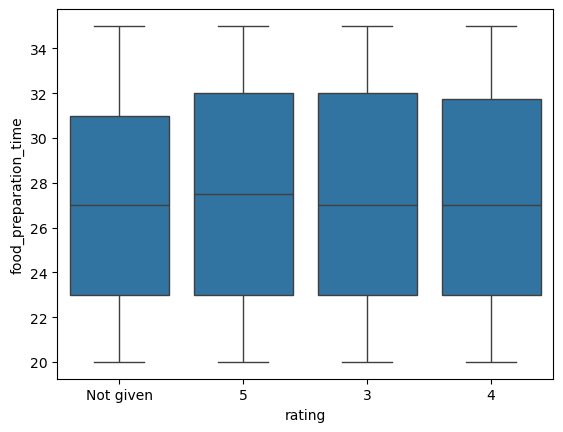

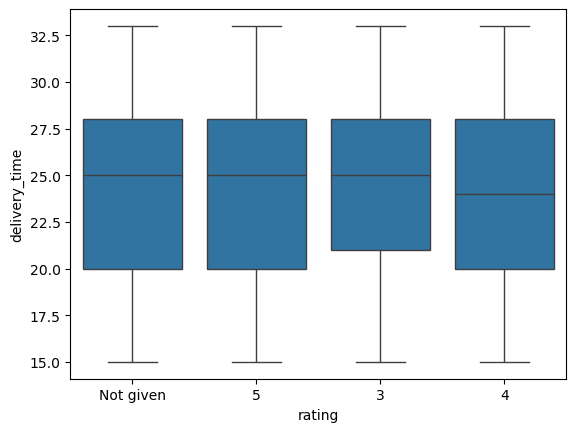

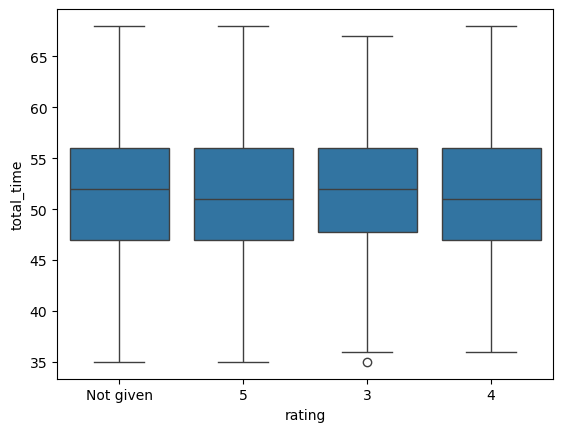

In [115]:
#Creating a df where we have both a total time column and the Not given values
df_time_NA = df.copy()
df_time_NA['total_time'] = df_time_NA['food_preparation_time'] + df_time_NA['delivery_time']

#Showing prep, delivery, and total time broken out by rating:
sns.boxplot(data=df_time_NA, x='rating', y='food_preparation_time')
plt.show()

sns.boxplot(data=df_time_NA, x='rating', y='delivery_time')
plt.show()

sns.boxplot(data=df_time_NA, x='rating', y='total_time')
plt.show()

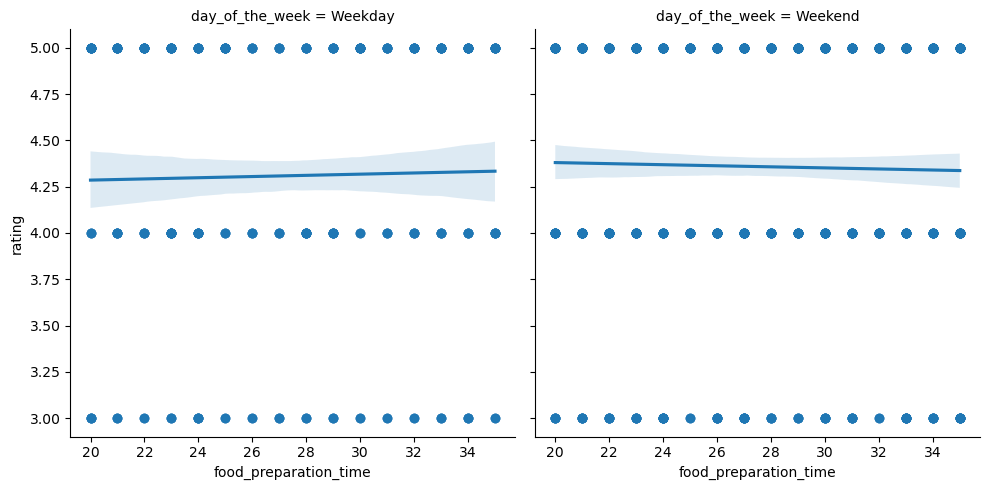

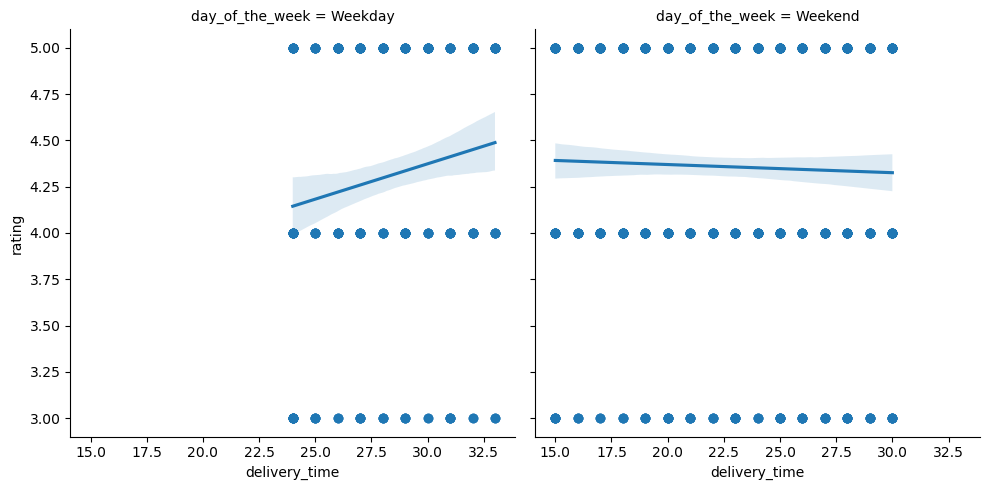

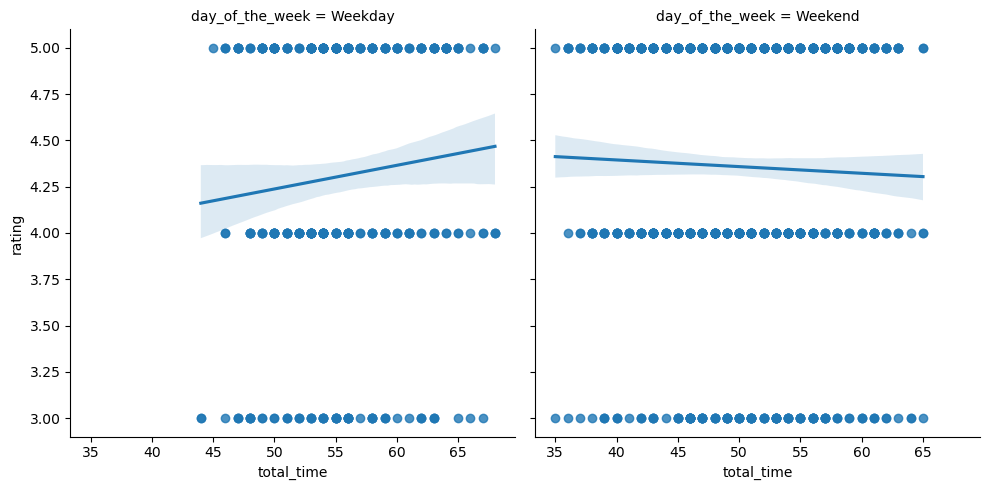

In [116]:
#Prep, delivery, and total time v rating broken out by weekday v weekend:

#Impact of prep time on rating weekday v weekend:
df_lm_3 = df_time[['food_preparation_time', 'rating', 'day_of_the_week']].dropna()
sns.lmplot(data=df_lm_3, x='food_preparation_time',y='rating', col='day_of_the_week')

#Impact of delivery time on rating weekday v weekend:
df_lm_4 = df_time[['delivery_time', 'rating', 'day_of_the_week']].dropna()
sns.lmplot(data=df_lm_4, x='delivery_time',y='rating', col='day_of_the_week')

#Impact of total time on rating weekday v weekend:
df_lm_2 = df_time[['total_time', 'rating', 'day_of_the_week']].dropna()
sns.lmplot(data=df_lm_2, x='total_time',y='rating', col='day_of_the_week')
plt.show()

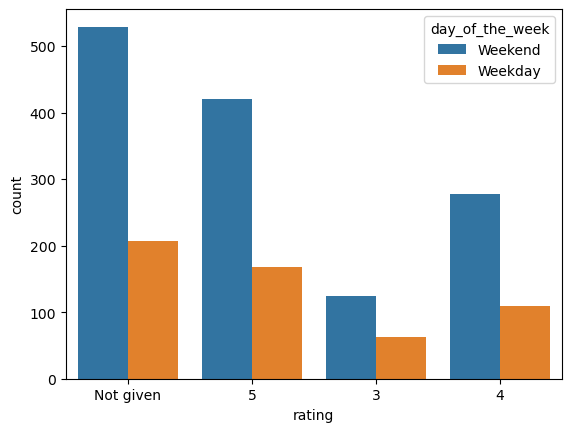

In [117]:
#Count of ratings given by week v weekend
sns.countplot(data=df, x='rating', hue='day_of_the_week')
plt.show()

Observations:

As we saw above, the ratings are not strongly correlated with delivery time, cost, or day of week.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [118]:
# Write the code here

#Above I already have defined: avg_ratings = df_c.groupby('restaurant_name')['rating'].mean().reset_index()

#Use this to make a >4 star list
greater_than_four_star = avg_ratings[avg_ratings['rating'] > 4].reset_index(drop=True)
greater_than_four_star.head()

,restaurant_name,rating
0,'wichcraft,5.0
1,12 Chairs,4.5
2,67 Burger,5.0
3,Amma,4.5
4,Anjappar Chettinad,5.0


In [119]:
#Counts of Ratings:
count_ratings= (df_c.groupby('restaurant_name')['rating'].count().reset_index(name='num_ratings'))

#Get only the ratings couts > 50:
count_ratings_over_50 = count_ratings[count_ratings['num_ratings'] > 50].reset_index(drop=True)
count_ratings_over_50

,restaurant_name,num_ratings
0,Blue Ribbon Fried Chicken,64
1,Blue Ribbon Sushi,73
2,Shake Shack,133
3,The Meatball Shop,84


In [120]:
#Merging to find the restaurants on both lists
promo_restaurants = greater_than_four_star.merge(count_ratings_over_50, on='restaurant_name', how='inner')
promo_restaurants

,restaurant_name,rating,num_ratings
0,Blue Ribbon Fried Chicken,4.328125,64
1,Blue Ribbon Sushi,4.219178,73
2,Shake Shack,4.278195,133
3,The Meatball Shop,4.511905,84


#### Observations:
There are 4 restaurants that meet the promotion conditions.

-Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [121]:
# Write the code here
sum_greater_20 = df[df['cost_of_the_order'] >20]['cost_of_the_order'].sum()
revenue_20 = sum_greater_20*.25

sum_greater_5 = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'].sum()
revenue_5 = sum_greater_5*.15

total_revenue = revenue_20 + revenue_5

print('Revenue from orders > 20 dollars:',revenue_20)
print('Revenue from orders > 5 dollars:',revenue_5)
print('Total Revenue:',total_revenue)

Revenue from orders > 20 dollars: 3688.7275
Revenue from orders > 5 dollars: 2477.5755000000004
Total Revenue: 6166.303


#### Observations:
Revenue = 6166.30 dollars.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [122]:
# Write the code here

#We already have the total times above:
(df_time[df_time['total_time'] > 60].shape[0]/df_time.shape[0])*100

10.537407797681771

#### Observations:

10.5% of orders took more than 60 minutes total from order to delivery.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [123]:
# Write the code here

#From above analysis we already have: rating_prep_delivery_total_by_day = rating_prep_delivery_by_day.merge(total_by_day, on='day_of_the_week', how='left')
rating_prep_delivery_total_by_day

,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,Weekday,4.308824,27.212066,28.340037,55.552102
1,Weekend,4.358881,27.436714,22.470022,49.906736


#### Observations:

Weekday total time takes 5.6 min longer on average.

This is driven by delivery time which is an average of 5.9 min longer on weekdays.

# Conclusion and Business Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

## Conclusions

**Ratings**
*   39% of orders were not rated
*   No rating below 3 was given
*   139 Restaurants (78%) rated > 4 with only 17 < 4 and none rating < 3
*   22 restaurants (12.4%) were never rated
*   For Not rated restaurants, the average time and cost per order are comparable to all restaurants, but total spend is much lower with only 3 re-orders from customers of the 22 not rated restaurants.  This implies that a lack of rating may be associated with poor quality or enjoyment of food.

**Repeat Ordering**
*   Average 1.6 orders per customer
*   Only 34.7% of customers made > 1 order; 5.5% >4 orders; max orders by customer = 13
*   30% of customers ordered from the same restaurant more once, but only 4% did 3 or more times.
*   There is almost no correlation between repeat ordering behavior and ratings. (Possibly impacted by the large number of orders that are not rated).

**Restaurant Performance**
*   Only 3 restaurants with > 100 total orders; Shake Shack #1 with 219 orders
*   28% of restaurants had only 1 order
*   Shake Shack had most repeat customers at 37

**Cuisine Type Performance**
*   American, Japanese, Italian, and Chinese are most popular making up 82.6% of all orders.
*   American food has most repeat customers and repeat orders.
*   Vietnamese is least ordered making up only .4% of total

**Cost Trends**
*   75% of customers spend $20.79 or less per order on average

**Day of Week Trends**
*   71.2% of orders were placed on weekends
*   Customers spent an average of 26 cents more per order on weekends vs. weekdays.
*   Weekday deliveries took an average of 6 min longer than weekend deliveries

**Wait Time Trends**
*   Number of orders drops at around the 30 min delivery time mark, with the outlier fence at ~40 min.




## Business Recommendations

**Ratings**
*   Check app for technical issue - is it not registering ratings below 3?
*   Send in-app rating reminders to customers or messages explaining the importance of ratings to delivering a high quality product.

**Repeat Ordering Behavior**
*   Build an algorithm that leverages a combination of repeat ordering data, and cuisine type preference to make recommendations.  After 2 orders, have the algorithm suggest a new restaurant of the same food type - "If you like this then try that" to match both preference and need for variety (not many people order from the same restaurant more than twice in the measured period).

**Restaurant Performance**
*   Base restaurant incentives on both rating and number of ratings as many have too little data to be reliable.

**Cuisine Type Performance**
*   When launching in new markets, begin with heavy focus on local cuisine type before growing variety.

**Cost**
*   When onboarding/expanding, target new restaurants with an average meal price of <$21.
*   Use individual customer spend data for targeted advertising that matches the customer's average spend per order +/- 6.59.

**Wait Time**
*   Deprioritize restaurants with >30 min delivery time in the recommendation algorithm (accounting for real time traffic and routing predictions).

**Day of Week**
*   Drive weekday sales with above recommendation to de-prioritize >30 min delivery times in real time.
*   If customer has location services turned on, using above algorithms to select a suggested restaurant in the customer's preferred cuisine type within 30 min delivery window with expected traffic, send in app reminder "Don't waste your lunch break cooking or driving, x meal from y restaurant can reach you at z time if you order in the next 10 minutes."







---

